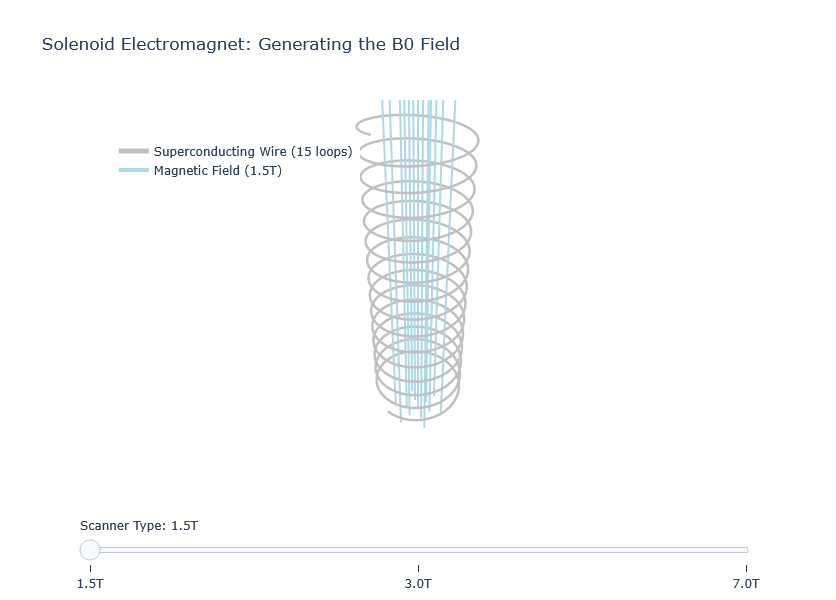

In [3]:
#| label: fig3

import numpy as np
import plotly.graph_objects as go

# 1. Setup the basic geometry
r_coil = 1.0
z_length = 4.0

# States representing different MRI field strengths
# Increasing B0 means more loops (N) and more current (I)
states = [
    {"b0": "1.5T", "loops": 15, "field_color": "lightblue", "line_width": 4},
    {"b0": "3.0T", "loops": 30, "field_color": "royalblue", "line_width": 8},
    {"b0": "7.0T", "loops": 60, "field_color": "red",       "line_width": 16}
]

frames = []
steps = []

for state in states:
    # Generate the wire helix (Solenoid)
    t = np.linspace(-z_length/2, z_length/2, 1000)
    x_coil = r_coil * np.cos(2 * np.pi * state["loops"] * (t - t[0]) / z_length)
    y_coil = r_coil * np.sin(2 * np.pi * state["loops"] * (t - t[0]) / z_length)
    z_coil = t
    
    coil_trace = go.Scatter3d(
        x=x_coil, y=y_coil, z=z_coil,
        mode='lines',
        line=dict(color='silver', width=5),
        name=f"Superconducting Wire ({state['loops']} loops)"
    )
    
    # Generate the magnetic field lines inside the bore
    field_lines = []
    # Create a bundle of lines in the center
    for radius in [0, 0.3, 0.6]:
        for angle in np.linspace(0, 2*np.pi, 6 if radius > 0 else 1, endpoint=False):
            x_f = [radius * np.cos(angle), radius * np.cos(angle)]
            y_f = [radius * np.sin(angle), radius * np.sin(angle)]
            z_f = [-z_length/1.5, z_length/1.5]
            
            field_lines.append(go.Scatter3d(
                x=x_f, y=y_f, z=z_f,
                mode='lines',
                line=dict(color=state["field_color"], width=state["line_width"]),
                showlegend=False,
                hoverinfo='skip'
            ))
            
    # Dummy trace for the legend of the field lines
    field_legend = go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode='lines',
        line=dict(color=state["field_color"], width=state["line_width"]),
        name=f"Magnetic Field ({state['b0']})"
    )
    
    frame_data = [coil_trace, field_legend] + field_lines
    frames.append(go.Frame(data=frame_data, name=state["b0"]))
    
    steps.append(dict(
        method="animate",
        args=[[state["b0"]], {"mode": "immediate", "frame": {"duration": 600, "redraw": True}, "transition": {"duration": 300}}],
        label=state["b0"]
    ))

# 3. Layout Configuration
fig = go.Figure(data=frames[0].data, frames=frames)

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False, range=[-1.5, 1.5]),
        yaxis=dict(visible=False, range=[-1.5, 1.5]),
        zaxis=dict(visible=False, range=[-2.5, 2.5]),
        aspectmode='data'
    ),
    sliders=[dict(active=0, currentvalue={"prefix": "Scanner Type: "}, pad={"t": 50}, steps=steps)],
    height=600,
    title="Solenoid Electromagnet: Generating the B0 Field",
    legend=dict(x=0.05, y=0.9)
)

fig